In [169]:
import torch 
from torch import nn 
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt 

In [170]:
transform = transforms.ToTensor() 

In [171]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = transform
)

In [172]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [173]:
np.unique(train_data.targets, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [174]:
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = transform
)

In [175]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [176]:
np.unique(test_data.targets, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

In [177]:
train_dataloader = DataLoader(dataset = train_data, batch_size =64)

In [178]:
test_dataloader = DataLoader(dataset = test_data, batch_size = 64)

In [179]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=28*28, out_features=512),

            nn.ReLU(),
            nn.Linear(in_features=512, out_features=512),

            nn.ReLU(),
            nn.Linear(in_features=512, out_features=10)   
        )
    def forward(self, x):
        x = self.flatten(x)
        network = self.linear_relu_stack(x)
        return network

In [180]:
simpleNN = NeuralNetwork()

In [181]:
simpleNN

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [182]:
loss_func = nn.CrossEntropyLoss()

In [183]:
opt = torch.optim.SGD(
    params = simpleNN.parameters(),
    lr = 1e-3
    )

In [184]:
def training(datalodader, model, loss_func, optimizer):

    size = len(datalodader.dataset)

    model.train()

    for batch, (x, y) in enumerate(datalodader):

        pred= model(x)
        loss = loss_func(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss = loss.item()
            current = batch * len(x)
            print(f"loss: {loss:>5f} at {current:>5d}/{size:>5d}")

In [185]:
def testing(dataloader, model, loss_func):
    size = len(dataloader.dataset)
    num_batch = len(dataloader)

    model.eval()

    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            pred = model(x)
            test_loss += loss_func(pred, y ).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batch
    correct /= size

    print(f"\n Test Evaluation: \n Accuracy: {(100 * correct):>5f}%. Avg loss: {test_loss:>5f} \n")

In [186]:
epochs = 5 

In [187]:
for t in range(5):
    print(f"\n\n    Epoch {t+1} ------------- \n")
    training(train_dataloader, simpleNN, loss_func, opt)
    testing(test_dataloader, simpleNN, loss_func)



    Epoch 1 ------------- 

loss: 2.289845 at     0/60000
loss: 2.283372 at  6400/60000
loss: 2.257886 at 12800/60000
loss: 2.257104 at 19200/60000
loss: 2.233860 at 25600/60000
loss: 2.202239 at 32000/60000
loss: 2.226630 at 38400/60000
loss: 2.181262 at 44800/60000
loss: 2.175987 at 51200/60000
loss: 2.153638 at 57600/60000

 Test Evaluation: 
 Accuracy: 37.270000%. Avg loss: 2.139732 



    Epoch 2 ------------- 

loss: 2.146389 at     0/60000
loss: 2.138386 at  6400/60000
loss: 2.081382 at 12800/60000
loss: 2.100737 at 19200/60000
loss: 2.035600 at 25600/60000
loss: 1.974872 at 32000/60000
loss: 2.022194 at 38400/60000
loss: 1.930114 at 44800/60000
loss: 1.937820 at 51200/60000
loss: 1.866827 at 57600/60000

 Test Evaluation: 
 Accuracy: 53.200000%. Avg loss: 1.860483 



    Epoch 3 ------------- 

loss: 1.894637 at     0/60000
loss: 1.861023 at  6400/60000
loss: 1.750645 at 12800/60000
loss: 1.794962 at 19200/60000
loss: 1.665863 at 25600/60000
loss: 1.623376 at 32000/60000
lo

In [191]:
labels = [
    "T-Shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

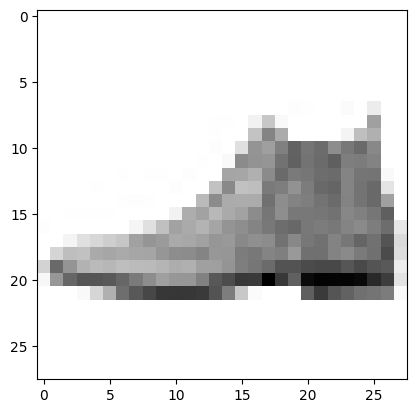

In [189]:
plt.imshow(test_data.data[0], cmap= "Greys")
x = test_data[0][0]
y = test_data[0][1]

In [193]:
with torch.no_grad():
    pred = simpleNN(x)
    prediction = labels[pred[0].argmax(0)]
    truth = labels[y]
    print(f"simpleNN predict as {prediction} ; truth is {truth}")

simpleNN predict as Ankle Boot ; truth is Ankle Boot
